In [ ]:
!pip install jaxopt

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxopt import LBFGS

In [ ]:
burnin = 1000
beta = 0.3
N = 1000
seed = 0
n = 15

In [ ]:
key = jax.random.key(seed)
key, key0 = jax.random.split(key,num=2)
jax.config.update("jax_enable_x64", True)

In [ ]:
@jax.jit
def phi(n):
  return 0.5*jnp.log(jnp.dot(n,n))

In [ ]:
@jax.jit
def project(v, n):
    return v - jnp.dot(v, n)/jnp.dot(n, n) * n

@jax.jit
def log_r(x, xi, nx, y, xi_prime, ny, beta):
  return phi(nx) - phi(ny) + 0.5 * (jnp.linalg.norm(x)**2 - jnp.linalg.norm(y)**2) + (1 / (2 * beta**2)) * (jnp.linalg.norm(xi)**2 - jnp.linalg.norm(xi_prime)**2)

@jax.jit
def compute_reverse(x, y, n):
    return project(x-y, n)

In [ ]:
def manifold(d, z=jnp.float64(0)):

    x_0 = jnp.float64(0)
    tt = 1
    dt = tt/d
    dW = jnp.sqrt(dt)
    t0=dt

    @jax.jit
    def diffusion():
        return 1

    @jax.jit
    def F_full(x):

        @jax.jit
        def drift(x):
            return 0

        @jax.jit
        def pathstep(x_i, rand_var):
            x_i += drift(x_i)*dt + diffusion()*dW*rand_var
            return x_i, x_i
        end, sample_path = jax.lax.scan(pathstep, x_0 ,x)

        return end - z, sample_path

    @jax.jit
    def F(x):
        out, _ = F_full(x)
        return out

    @jax.jit
    def x0():
      return jnp.zeros((d,),dtype=jnp.float64).at[d-1].set(diffusion() * z/dW)

    @jax.jit
    def nx0():
        return jax.grad(F)(x0())

    @jax.jit
    def manifoldproject(x, n, tol=1e-3, maxiter=100):
        def f(val):
            a,i = val
            ff = lambda a: F(x + a * n)
            fff = ff(a)
            dff = jax.grad(ff)(a)
            return (a-fff/dff, i+1)
        def cond(val):
            a,i = val
            return jnp.logical_and(jnp.abs(F(x + a * n))>tol,i<maxiter)
        a,_ = jax.lax.while_loop(cond, f, (0.0,0))
        success = lambda a: jnp.abs(F(x + a * n))<tol
        return jnp.where(success(a), x + a * n, x)

    return F, x0, nx0, manifoldproject, F_full

In [ ]:
def RWMH(key, beta, d=10):
    F, x0, nx0, manifoldproject, F_full = manifold(d)
    keylist = jax.random.split(key, N+burnin)

    def sampleStep(carry, current_key):
        (x, nx, accs, it) = carry

        v = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        v_prime = compute_reverse(x, y, ny)
        R = log_r(x, v, nx, y, v_prime, ny, beta)
        acc = (jnp.log(jax.random.uniform(current_key)) < R)
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        accs += jnp.where(it>burnin, acc, 0)
        it += 1
        return (x, nx, accs, it), (R, x)

    (_, _, accs, _), (Rs, xs) = jax.lax.scan(sampleStep, (x0(), nx0(), 0, 0), keylist)
    _, path = F_full(xs[-1])

    return np.mean(Rs[burnin:]), accs/N, np.array(path)

In [ ]:
stats = []
rs = []
test_x = np.int64(2**jnp.linspace(1,n,n))

for test_dim in test_x:

  r, out, path = RWMH(key, beta, test_dim)
  stats = np.append(stats, out)
  rs = np.append(rs, r)

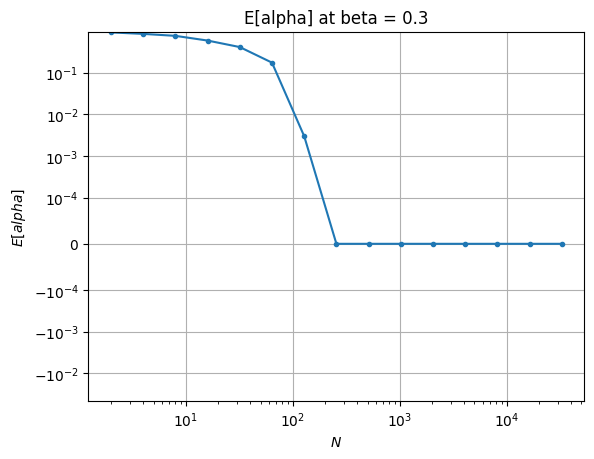

In [ ]:
plt.plot(test_x, stats,'.-')
plt.xscale('log')
plt.yscale('symlog',linthresh=1e-4)
plt.title('E[alpha] at beta = 0.3')
plt.xlabel('$N$')
plt.ylabel(r'$E[alpha]$')
plt.grid()

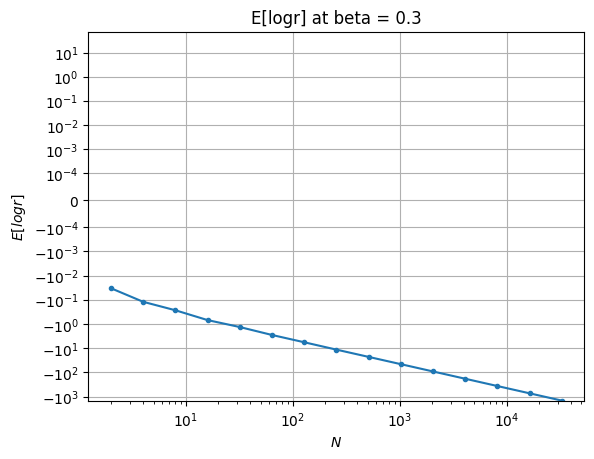

In [ ]:
plt.plot(test_x, rs,'.-')
plt.xscale('log')
plt.yscale('symlog',linthresh=1e-4)
plt.title('E[logr] at beta = 0.3')
plt.xlabel('$N$')
plt.ylabel(r'$E[logr]$')
plt.grid()

In [ ]:
scaled_stats = []
scaled_rs = []

for test_dim in test_x:

  beta = test_dim**(-0.5)
  r, out, path = RWMH(key, beta, test_dim)
  scaled_stats = np.append(scaled_stats, out)
  scaled_rs = np.append(scaled_rs, r)

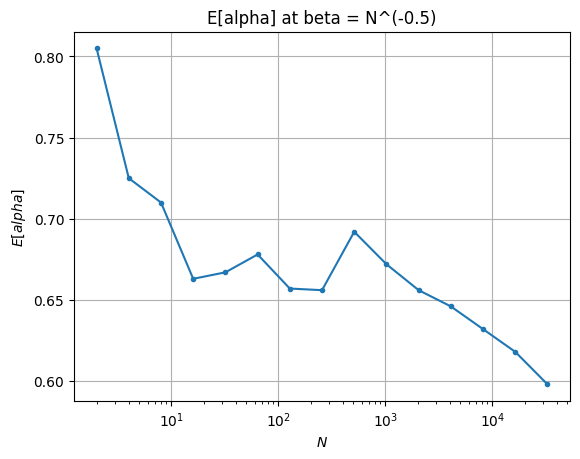

In [ ]:
plt.plot(test_x, scaled_stats,'.-')
plt.xscale('log')
plt.title('E[alpha] at beta = N^(-0.5)')
plt.xlabel('$N$')
plt.ylabel(r'$E[alpha]$')
plt.grid()

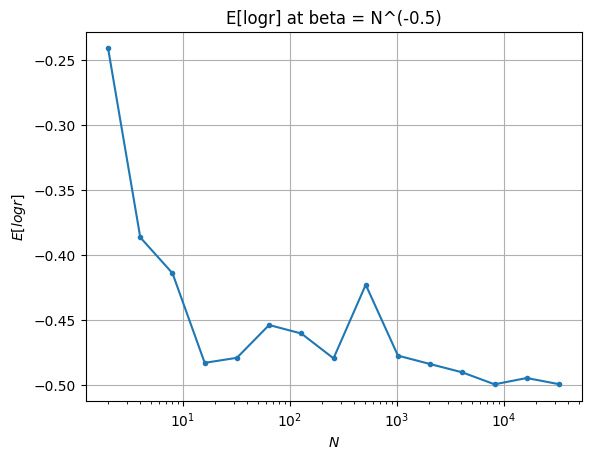

In [ ]:
plt.plot(test_x, scaled_rs,'.-')
plt.xscale('log')
plt.title('E[logr] at beta = N^(-0.5)')
plt.xlabel('$N$')
plt.ylabel(r'$E[logr]$')
plt.grid()